# Random Forest: Student Pass/Fail Prediction

## Problem
Predict whether a student will **pass (1)** or **fail (0)** from study hours, attendance and previous score.

## Objective
See how combining **many decision trees** gives a more stable and accurate model than a single tree, and learn how to read feature importance.

**Dataset:** `data/student_pass_fail.csv` (300 rows). The data is **synthetic** (randomly generated with a fixed seed by `data/generate_data.py`) for learning purposes. It does not describe real students.

| Column | Meaning |
|--------|---------|
| `study_hours` | Daily study hours (0 to 10) |
| `attendance_pct` | Attendance percentage (50 to 100) |
| `previous_score` | Score in the previous exam (20 to 100) |
| `passed` | 1 = passed, 0 = failed (target) |

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## 2. Load the Dataset and Split

In [2]:
from pathlib import Path

def find_data(filename):
    """Find data/<filename> by searching this notebook's folder and its parent folders."""
    here = Path.cwd().resolve()
    for folder in [here, *here.parents]:
        candidate = folder / "data" / filename
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find data/{filename}. Open this notebook from inside the project folder."
    )


In [3]:
df = pd.read_csv(find_data("student_pass_fail.csv"))
features = ["study_hours", "attendance_pct", "previous_score"]
X = df[features]
y = df["passed"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Shape:", df.shape, "| Training rows:", len(X_train), "| Test rows:", len(X_test))

Shape: (300, 4) | Training rows: 240 | Test rows: 60


## 3. How a Random Forest Works

A single decision tree is unstable and overfits. A **random forest** fixes this with two ideas:

1. Build **many trees**, each on a different random sample of the students (and a random subset of features at each split).
2. Let all the trees **vote**. The majority answer is the final prediction.

Individual trees make different mistakes, and the voting **averages the mistakes out**. This technique of combining models is called an **ensemble**.

## 4. Train the Forest

In [4]:
forest = RandomForestClassifier(n_estimators=200, random_state=42)
forest.fit(X_train, y_train)
pred = forest.predict(X_test)

print(f"Train accuracy: {forest.score(X_train, y_train):.3f}")
print(f"Test accuracy : {accuracy_score(y_test, pred):.3f}\n")
print(classification_report(y_test, pred, target_names=["Fail", "Pass"]))

Train accuracy: 1.000
Test accuracy : 0.867

              precision    recall  f1-score   support

        Fail       0.82      0.97      0.89        33
        Pass       0.95      0.74      0.83        27

    accuracy                           0.87        60
   macro avg       0.89      0.86      0.86        60
weighted avg       0.88      0.87      0.86        60



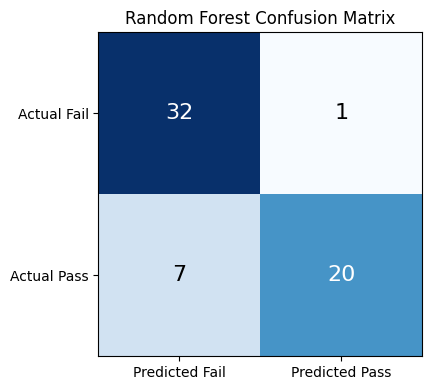

In [5]:
def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4.5, 4))
    ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1], ["Predicted Fail", "Predicted Pass"])
    ax.set_yticks([0, 1], ["Actual Fail", "Actual Pass"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=16,
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

plot_confusion(y_test, pred, "Random Forest Confusion Matrix")

Training accuracy is 100%, which means each tree still memorizes its training sample. The test accuracy is the number that matters, and it is clearly better than what a single deep tree gave.

## 5. How Many Trees Are Enough?

More trees give a more stable vote, but only up to a point.

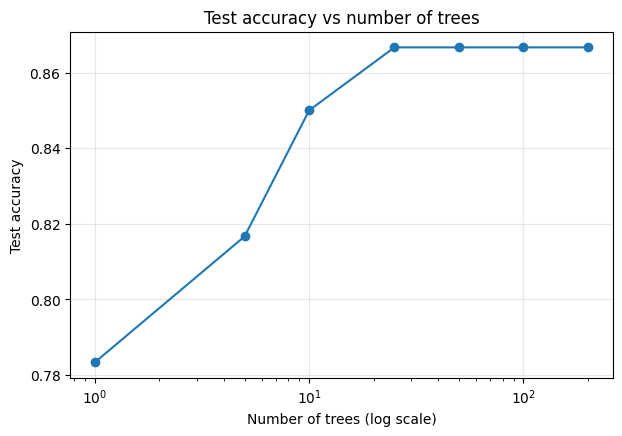

,trees,test accuracy
0,1,0.783
1,5,0.817
2,10,0.850
3,25,0.867
4,50,0.867
5,100,0.867
6,200,0.867


In [6]:
tree_counts = [1, 5, 10, 25, 50, 100, 200]
scores = [RandomForestClassifier(n_estimators=n, random_state=42).fit(X_train, y_train).score(X_test, y_test)
          for n in tree_counts]

plt.figure(figsize=(7, 4.5))
plt.plot(tree_counts, scores, marker="o")
plt.xscale("log")
plt.title("Test accuracy vs number of trees")
plt.xlabel("Number of trees (log scale)")
plt.ylabel("Test accuracy")
plt.grid(alpha=0.3)
plt.show()

pd.DataFrame({"trees": tree_counts, "test accuracy": np.round(scores, 3)})

A forest with a **single tree** performs like one weak decision tree. Accuracy rises quickly as trees are added and then **flattens**, so adding hundreds more trees would not help.

## 6. Forest vs Single Tree

We compare against one decision tree of depth 5 (the depth chosen by cross-validation in the previous notebook).

In [7]:
single_tree = DecisionTreeClassifier(max_depth=5, random_state=42).fit(X_train, y_train)

pd.DataFrame({
    "Model": ["Single Decision Tree (depth 5)", "Random Forest (200 trees)"],
    "Train accuracy": [single_tree.score(X_train, y_train), forest.score(X_train, y_train)],
    "Test accuracy": [single_tree.score(X_test, y_test), forest.score(X_test, y_test)],
}).round(3)

,Model,Train accuracy,Test accuracy
0,Single Decision Tree (depth 5),0.933,0.783
1,Random Forest (200 trees),1.000,0.867


## 7. Reduce Overfitting by Limiting the Trees

We can stop each tree from memorizing by limiting its depth and requiring a minimum number of students per leaf.

In [8]:
forest_small = RandomForestClassifier(n_estimators=200, max_depth=4, min_samples_leaf=5, random_state=42)
forest_small.fit(X_train, y_train)

print(f"Train accuracy: {forest_small.score(X_train, y_train):.3f}")
print(f"Test accuracy : {forest_small.score(X_test, y_test):.3f}")

Train accuracy: 0.904
Test accuracy : 0.867


The test accuracy is the same, but the gap between train and test is much smaller. The model is simpler and no less accurate, which is a better result.

## 8. Which Features Matter Most?

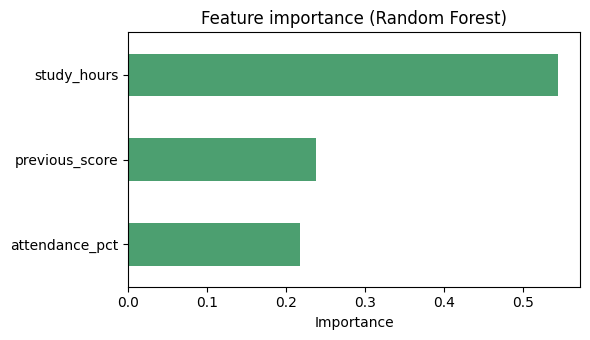

attendance_pct    0.218
previous_score    0.237
study_hours       0.545
dtype: float64

In [9]:
importance = pd.Series(forest.feature_importances_, index=features).sort_values()

plt.figure(figsize=(6, 3.5))
importance.plot(kind="barh", color="#4C9F70")
plt.title("Feature importance (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

importance.round(3)

## Conclusion

- A random forest of 200 trees reaches a test accuracy of about **87%**, compared with about **78%** for a single decision tree.
- Accuracy stops improving after roughly 25 trees.
- Limiting the depth keeps the same accuracy while reducing overfitting.
- `study_hours` is the most important feature (about 55%), but attendance and previous score contribute too. A forest spreads importance more evenly than a single tree.
- Precision for Pass is very high (about 95%), but recall is about 74%: like the other models, it is cautious and misses some students who passed.
- The cost is **less interpretability**: unlike a single tree, you cannot read 200 trees as a flowchart.